# SUPERVISED MACHINE LEARNING

`1. Linear Regression Model`

## Importing Necessary Libraries

In [78]:
import pandas as pd
import numpy as np
# Import the tools
from sklearn.model_selection import train_test_split, GridSearchCV
# Import the model
from sklearn.linear_model import LinearRegression
# Importing metrics to evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Import matplotlib and seaborn for plotting
import matplotlib.pyplot as plt
import seaborn as sns
# Importing the decision tree regressor and visualizer
from sklearn.tree import DecisionTreeRegressor, plot_tree




## Loading the dataset

In [45]:
students_df = pd.read_csv("../data/Student_Marks.csv")

In [46]:
students_df.head()

,number_courses,time_study,Marks
0,3,4.508,19.202
1,4,0.096,7.734
2,4,3.133,13.811
3,6,7.909,53.018
4,8,7.811,55.299


`Objective: Predict Student marks using the features number_courses and time_study`

## Basic Checks

In [47]:
def basic_checks (data):
    print("="*20, "MISSING VALUES","="*20)
    print(data.isnull().sum())
    print("="*20, "DUPLICATES","="*20)
    print(data.duplicated().sum())
    print("="*20, "DATA TYPES","="*20)
    print(data.dtypes)
    print("="*20, "STATS","="*20)
    display(data.describe().T)

In [48]:
basic_checks(students_df)

==================== MISSING VALUES ====================
number_courses    0
time_study        0
Marks             0
dtype: int64
==================== DUPLICATES ====================
0
==================== DATA TYPES ====================
number_courses      int64
time_study        float64
Marks             float64
dtype: object
==================== STATS ====================


,count,mean,std,min,25%,50%,75%,max
number_courses,100.0,5.29000,1.799523,3.000,4.0000,5.0000,7.00000,8.000
time_study,100.0,4.07714,2.372914,0.096,2.0585,4.0220,6.17925,7.957
Marks,100.0,24.41769,14.326199,5.609,12.6330,20.0595,36.67625,55.299


## Defining the features (X) and targets (y)

In [49]:
X = students_df[["number_courses", "time_study"]]
y = students_df["Marks"]

print(X.shape)
print(y.shape)

(100, 2)
(100,)


## Splitting the data

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size= 0.2, 
                                                    random_state= 42
                                                    )

In [51]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(80, 2)
(20, 2)
(80,)
(20,)


## Creating The Linear Regression Model

In [52]:
model = LinearRegression()

## Train the model

In [53]:
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Inspecting the model
`model.coef_` will return the coefficients based on the features

In [54]:
model.coef_

array([1.87154988, 5.16987176])

In [55]:
model.intercept_

np.float64(-6.613046733912942)

In [56]:
for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, coefficient)
print("Intercept:", model.intercept_)

number_courses 1.8715498842079532
time_study 5.169871764839376
Intercept: -6.613046733912942


## Make predictions on the X_test

In [57]:
y_pred = model.predict(X_test)

In [58]:
print(y_pred)

[19.27278272 37.76035676 20.18779372  9.65670863 10.97508223 44.81200554
 13.34810968 47.62447209 37.01567001 22.30738483 44.48113375 28.33573684
  7.42332402 38.70638699 28.10820618 48.74122069 35.72331468 39.30103485
 28.29432156  8.94326632]


In [59]:
results = pd.DataFrame({
    "Actual_marks": y_test,
    "Predicted_marks": y_pred
})

results.head()

,Actual_marks,Predicted_marks
83,16.106,19.272783
53,36.653,37.760357
70,16.606,20.187794
45,8.924,9.656709
44,9.742,10.975082


## Calculate Residuals


In [60]:
results["Residuals"] = results["Actual_marks"] - results["Predicted_marks"]

results.head(20)

,Actual_marks,Predicted_marks,Residuals
83,16.106,19.272783,-3.166783
53,36.653,37.760357,-1.107357
70,16.606,20.187794,-3.581794
45,8.924,9.656709,-0.732709
44,9.742,10.975082,-1.233082
39,51.142,44.812006,6.329994
22,12.209,13.348110,-1.139110
80,54.321,47.624472,6.696528
10,42.036,37.015670,5.020330
0,19.202,22.307385,-3.105385


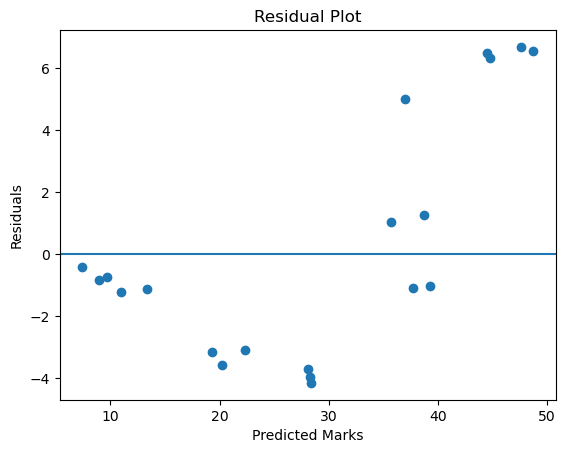

In [61]:
plt.scatter(y_pred, results["Residuals"])
plt.axhline(y=0)
plt.xlabel("Predicted Marks")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## Evaluating the model

In [62]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE: ",mae)
mse = mean_squared_error(y_test, y_pred)
print("MSE : ", mse)
rmse = np.sqrt(mse)
print("RMSE: ", rmse)
r2 = r2_score(y_test, y_pred)
print("R2 SCORE: ", r2)

MAE:  3.0793452296666857
MSE :  14.200726136374573
RMSE:  3.7683850833446644
R2 SCORE:  0.9459936100591213


## Calculating The R2 Score of the training Data

In [63]:
y_train_pred = model.predict(X_train)

In [64]:
train_r2 = r2_score(y_train, y_train_pred)
print("Training r2 score: ", train_r2)
print("Test r2 score: ", r2)

Training r2 score:  0.9343515936559419
Test r2 score:  0.9459936100591213


`2.Decision Tree Regressor`

## Creating the tree model

In [65]:
tree_model = DecisionTreeRegressor( 
    max_depth=3,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

## Training the model

In [66]:
tree_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,4
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


## Making prediction

In [67]:
tree_train_pred = tree_model.predict(X_train)
tree_test_pred = tree_model.predict(X_test)

## Calculating r2 Score

In [68]:
tree_train_r2 = r2_score(y_train, tree_train_pred)
tree_test_r2 = r2_score(y_test, tree_test_pred)

In [69]:
print("Decision Tree Training R2:", tree_train_r2)
print("Decision Tree Test R2:", tree_test_r2)

Decision Tree Training R2: 0.9625568850113893
Decision Tree Test R2: 0.9667729081755456


## Calculating MAE, MSE, and RMSE

In [70]:
tree_mae = mean_absolute_error(y_test, tree_test_pred)
tree_mse = mean_squared_error(y_test, tree_test_pred)
tree_rmse = tree_mse ** 0.5

In [71]:
print("Decision Tree MAE:", tree_mae)
print("Decision Tree MSE:", tree_mse)
print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree Training R2:", tree_train_r2)
print("Decision Tree Test R2:", tree_test_r2)

Decision Tree MAE: 2.5116061403508767
Decision Tree MSE: 8.736907462687
Decision Tree RMSE: 2.955826020368418
Decision Tree Training R2: 0.9625568850113893
Decision Tree Test R2: 0.9667729081755456


## Visualizing the tree

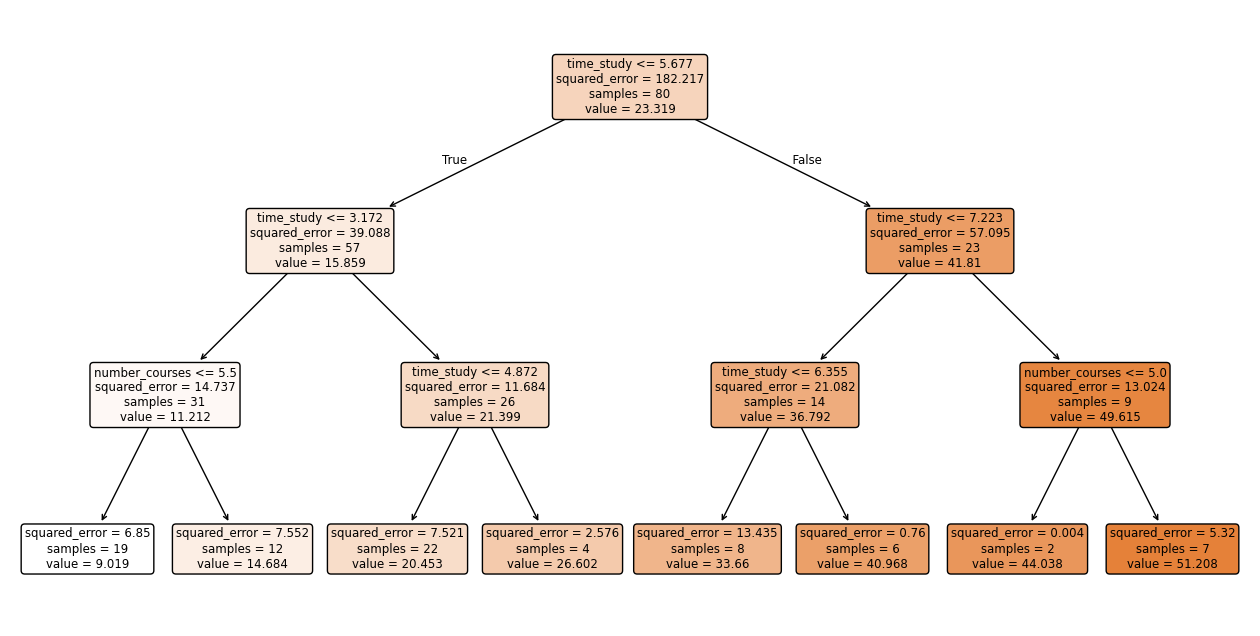

In [91]:
plt.figure(figsize=(16, 8))

plot_tree(
    tree_model,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.show()

## Checking Feature Importance

In [73]:

for feature, importance in zip(X.columns, tree_model.feature_importances_):
    print(feature, importance)

number_courses 0.02252370670721035
time_study 0.9774762932927896


## Tuning the hyperparameters

In [74]:
depths = [1,2,3,4,5,6,7,8]
train_r2_score_list = []
test_r2_score_list = []

for depth in depths:
    tree = DecisionTreeRegressor(
        max_depth= depth,
        min_samples_split= 4,
        min_samples_leaf= 2,
        random_state= 42
    )

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_r2_score = r2_score(y_train, train_pred)
    test_r2_score = r2_score(y_test, test_pred)

    train_r2_score_list.append(train_r2_score)
    test_r2_score_list.append(test_r2_score)

    print("Max_depth: ", depth,
          "Train r2 score: ", train_r2_score,
          "Test r2 score: ", test_r2_score
          )

Max_depth:  1 Train r2 score:  0.7570771544650909 Test r2 score:  0.8021396605168495
Max_depth:  2 Train r2 score:  0.9195343180885456 Test r2 score:  0.9533939870799809
Max_depth:  3 Train r2 score:  0.9625568850113893 Test r2 score:  0.9667729081755456
Max_depth:  4 Train r2 score:  0.9888625815854106 Test r2 score:  0.9783716306383444
Max_depth:  5 Train r2 score:  0.9931734526539456 Test r2 score:  0.9842055471583652
Max_depth:  6 Train r2 score:  0.9949739909711504 Test r2 score:  0.9851469111972126
Max_depth:  7 Train r2 score:  0.9959266547884436 Test r2 score:  0.985749001460985
Max_depth:  8 Train r2 score:  0.9962648214775575 Test r2 score:  0.985749001460985


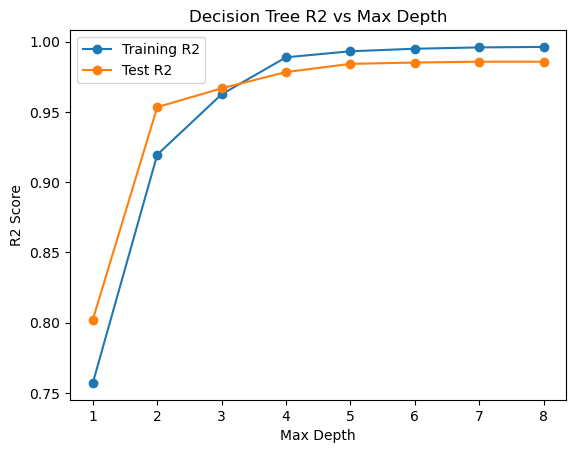

In [75]:
plt.plot(depths, train_r2_score_list, marker="o", label="Training R2")
plt.plot(depths, test_r2_score_list, marker="o", label="Test R2")

plt.xlabel("Max Depth")
plt.ylabel("R2 Score")
plt.title("Decision Tree R2 vs Max Depth")
plt.legend()
plt.show()

In [76]:
split_values = [2, 4, 6, 8, 10, 12, 15, 20]

train_r2_split = []
test_r2_split = []

for split in split_values:
    tree = DecisionTreeRegressor(
        max_depth= 7,
        min_samples_split= split,
        min_samples_leaf=2,
        random_state= 42
    )

    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_r2_split.append(train_r2)
    test_r2_split.append(test_r2)

    print("min_samples_split:", split,
        "Train R2:", train_r2,
        "Test R2:", test_r2
        )

min_samples_split: 2 Train R2: 0.9959266547884436 Test R2: 0.985749001460985
min_samples_split: 4 Train R2: 0.9959266547884436 Test R2: 0.985749001460985
min_samples_split: 6 Train R2: 0.9951148068119571 Test R2: 0.9850214869078174
min_samples_split: 8 Train R2: 0.9905717550544137 Test R2: 0.9778291875728031
min_samples_split: 10 Train R2: 0.9785101748763773 Test R2: 0.9562071911645726
min_samples_split: 12 Train R2: 0.9785101748763773 Test R2: 0.9562071911645726
min_samples_split: 15 Train R2: 0.9595378397662594 Test R2: 0.9617088046590363
min_samples_split: 20 Train R2: 0.9508963849786712 Test R2: 0.9687043387467621


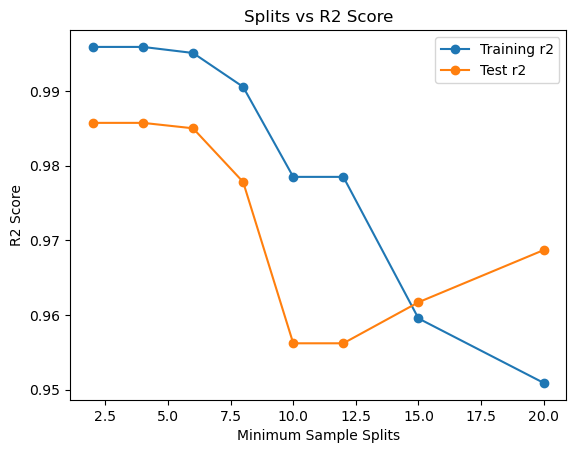

In [77]:
plt.plot(split_values,train_r2_split,marker = "o", label = "Training r2")
plt.plot(split_values, test_r2_split, marker = "o", label = "Test r2")

plt.xlabel("Minimum Sample Splits")
plt.ylabel("R2 Score")
plt.title("Splits vs R2 Score")
plt.legend()

plt.show()

### Cross-Validation 
#### GridSearchCV

In [79]:
param_grid = {
    "max_depth": [2, 3, 4, 5, 6, 7, 8],
    "min_samples_split": [2, 4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 3, 4, 5]
}

In [81]:
# Creating a normal tree regressor
tree = DecisionTreeRegressor(random_state=42)

# Creating the GridSearchCV
grid_search = GridSearchCV(
    estimator= tree,
    param_grid= param_grid,
    cv= 5,
    scoring="r2"
)

In [82]:
grid_search.fit(X_train, y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...]}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [83]:
# Best parameters
grid_search.best_params_

{'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2}

In [84]:
# Best score from the best params
grid_search.best_score_

np.float64(0.9649577850511504)

In [85]:
print("Best parameters:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)

Best parameters: {'max_depth': 8, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV R2: 0.9649577850511504


## Best Tree Model from the GridSearchCV

In [87]:
best_tree = grid_search.best_estimator_

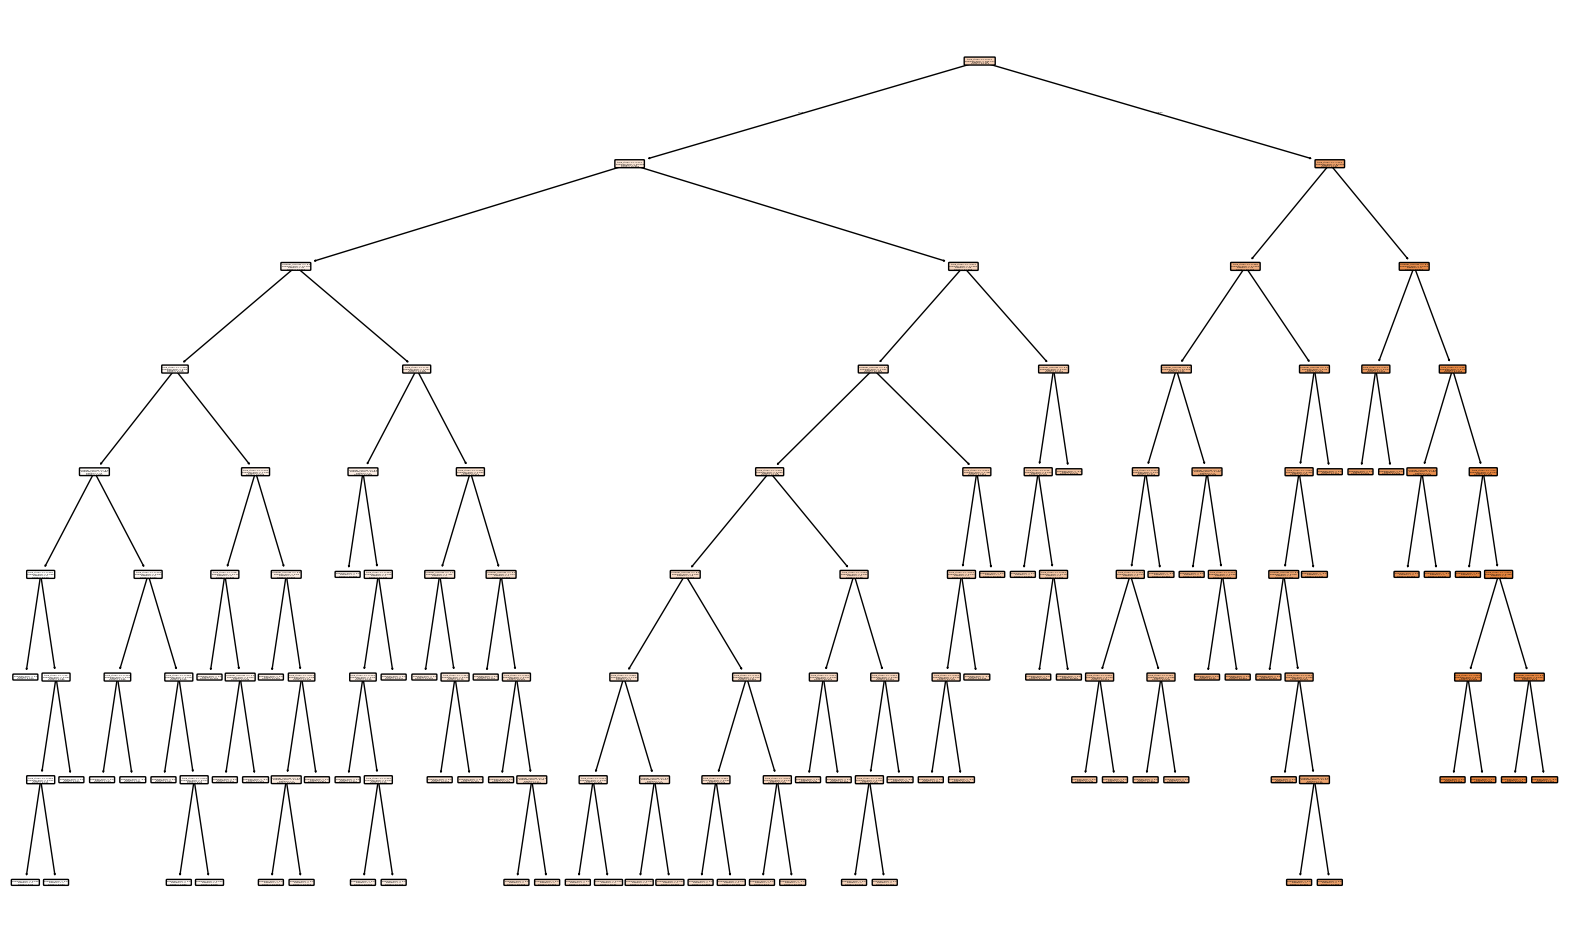

In [90]:
plt.figure(figsize=(20, 12))

plot_tree(
    best_tree,
    feature_names=X.columns,
    filled=True,
    rounded=True
)

plt.show()

## Making Predictions on the test data